In [ ]:
# Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
# Reshape & Normalize
x_train = x_train.reshape(-1,28,28,1).astype("float32") / 255.0
x_test = x_test.reshape(-1,28,28,1).astype("float32") / 255.0


In [ ]:
# One hot encoding ( label encoding )
y_train = tf.keras.utils.to_categorical(y_train,num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

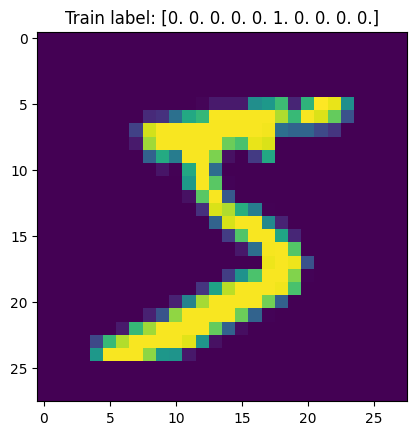

In [ ]:
# Visualise (Optional)
plt.imshow(x_train[0].reshape(28,28))
plt.title(f"Train label: {y_train[0]}")
plt.show()

In [ ]:
# BUILD CNN MODEL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Create model
model = Sequential()

In [ ]:
# First layer - Convolutional 32 filters, 3x3 with stride 1 and padding = 'same'
model.add(Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu', input_shape=(28,28,1)))

In [ ]:
# Maxpooling layer wtih 2x2 size
model.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
# Second convolution layers with 64 filters, 3x3 and same padding and strides = 1
model.add(Conv2D(64, (3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
# Dropout for Regularization (Drop 25% neurons)
model.add(Dropout(0.25))

In [ ]:
#Flatten before dense layer
model.add(Flatten())

In [ ]:
# Add dense layer
model.add(Dense(128, activation='relu'))

In [ ]:
# Dropout for Regularization (Drop 25% neurons)
model.add(Dropout(0.5))

In [ ]:
# Add dense layer
model.add(Dense(10, activation='softmax'))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
model.fit(x_train, y_train, epochs=10, batch_size = 128, validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9054 - loss: 0.3027 - val_accuracy: 0.9805 - val_loss: 0.0603
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9699 - loss: 0.1003 - val_accuracy: 0.9873 - val_loss: 0.0406
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9776 - loss: 0.0761 - val_accuracy: 0.9894 - val_loss: 0.0329
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9813 - loss: 0.0632 - val_accuracy: 0.9903 - val_loss: 0.0299
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9829 - loss: 0.0536 - val_accuracy: 0.9907 - val_loss: 0.0285
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9849 - loss: 0.0487 - val_accuracy: 0.9911 - val_loss: 0.0262
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9868 - loss: 0.0419 - val_accuracy: 0.9913 - val_loss: 0.0257
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0399 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9930 - loss: 0.0210
Test accuracy: 0.9929999709129333
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Predicted label: 7
True label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


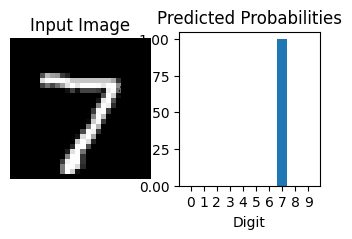

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Predict on a test image
index = 0  # Change this to try different test images
test_image = x_test[index]  # Shape: (28, 28)
prediction = model.predict(np.expand_dims(test_image, axis=0))  # Add batch dim: (1, 28, 28)

# Output prediction
predicted_label = np.argmax(prediction)
print("Predicted label:", predicted_label)
print("True label:", y_test[index])

# Visualization
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray')
plt.title(f"Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(10), prediction[0])
plt.title(f"Predicted Probabilities")
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.xticks(range(10))
plt.show()
